In [12]:
suppressPackageStartupMessages(library(tidyverse))
library(here)

options(box.path = here())
box::use(r / load)

r_out <- here("reports", "figures")
model_path <- here("data", "models", "views_elite_cdu")

PLOT_WIDTH <- 9
PLOT_HEIGHT <- 6


In [ ]:
read_model <- function(base_path, model_file) {
    fpath <- here(base_path, model_file)
    readRDS(fpath)
}

create_summary <- function(model, var) {
    model_summary <- summary(model)

    print(model_summary$fixed)

    df <- model_summary$fixed |>
        rownames_to_column("term") |>
        filter(term == !!var) |> 
        rename(est = Estimate, upper_ci = `u-95% CI`, lower_ci = `l-95% CI`, rhat = Rhat) |>
        select(lower_ci, est, upper_ci, rhat)

    return(df)
}

read_files <- function() {
    channels <- list.dirs(here(model_path), recursive = F, full.names = F)

    dfs <- list()
    i <- 0
    for (channel in channels) {
        print(channel)
        model_files <- list.files(here(model_path, channel), recursive = F, full.names = F)
        for (model_file in model_files) {
            print(model_file)
            quantile <- str_extract(model_file, "\\d+") |> as.integer()
            model <- read_model(here(model_path, channel), model_file)

            i <- i + 1
            sub_df <- create_summary(model, "elite") |>
                mutate(
                    quantile = quantile,
                    channel = channel
                )
            dfs[[i]] <- sub_df
        }
    }
    bind_rows(dfs)
}


In [35]:
df <- read_files()

[1] "cdu de"
[1] "q50.rds"
                       Estimate  Est.Error    l-95% CI  u-95% CI     Rhat Bulk_ESS Tail_ESS
Intercept          5.7063297706 0.59717007  4.53572568 6.9347085 1.002387 2564.364 2708.812
log_n_sents        0.2301401323 0.04828230  0.13555450 0.3249431 1.000796 4972.550 5406.728
released_year2018  0.2289829581 0.58120831 -0.98707585 1.3807096 1.002435 2369.573 2359.543
released_year2019  0.1805356100 0.58103761 -1.03285077 1.3304546 1.002507 2362.126 2422.392
released_year2020  0.2274192402 0.58276172 -0.97753090 1.3681237 1.002380 2382.868 2533.483
released_year2021  0.7080805148 0.58082495 -0.50924660 1.8609926 1.002619 2348.161 2393.762
released_year2022 -0.0009681898 0.58241478 -1.20484904 1.1456333 1.002509 2358.714 2393.111
released_year2023  2.0229305382 0.59451784  0.79410247 3.1952521 1.002274 2356.853 2538.996
released_year2024  1.6572865760 0.58367008  0.44995405 2.7891181 1.002355 2371.098 2384.444
released_year2025  1.8151164001 0.58974890  0.5834344

: [1m[33mError[39m in `filter()`:[22m
[1m[22m[36mℹ[39m In argument: `term == "elite"`.
[1mCaused by error:[22m
[33m![39m object 'term' not found

In [29]:
df

                            lower_ci           est   upper_ci      rhat quantile channel
Intercept...1            4.535725677  5.7063297706  6.9347085 1.0023868       50  cdu de
log_n_sents...2          0.135554503  0.2301401323  0.3249431 1.0007955       50  cdu de
released_year2018...3   -0.987075849  0.2289829581  1.3807096 1.0024351       50  cdu de
released_year2019...4   -1.032850772  0.1805356100  1.3304546 1.0025072       50  cdu de
released_year2020...5   -0.977530900  0.2274192402  1.3681237 1.0023805       50  cdu de
released_year2021...6   -0.509246600  0.7080805148  1.8609926 1.0026187       50  cdu de
released_year2022...7   -1.204849045 -0.0009681898  1.1456333 1.0025086       50  cdu de
released_year2023...8    0.794102475  2.0229305382  3.1952521 1.0022743       50  cdu de
released_year2024...9    0.449954046  1.6572865760  2.7891181 1.0023547       50  cdu de
released_year2025...10   0.583434462  1.8151164001  2.9639540 1.0024262       50  cdu de
is_shortTRUE...11    

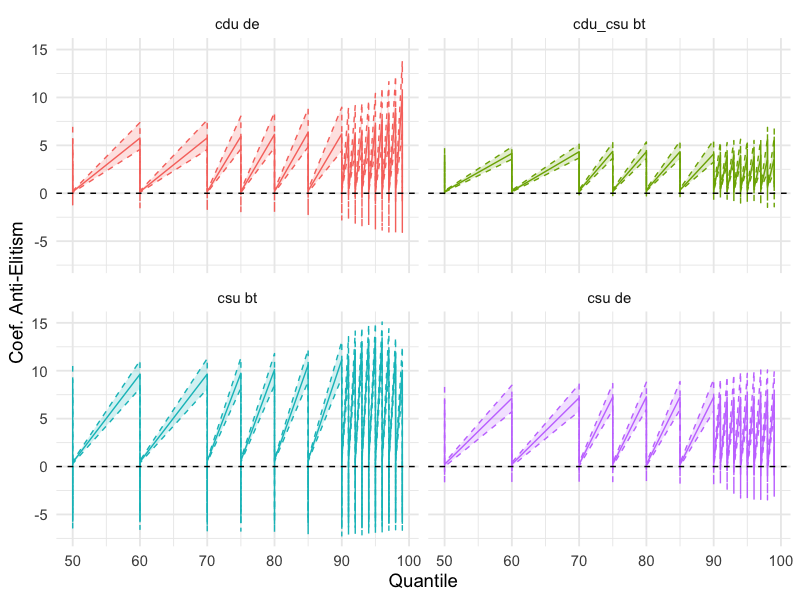

In [28]:
plot <- df |>
    ggplot(aes(x = quantile, y = est, color = channel, fill = channel)) +
    geom_line() +
    geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci), linetype = 2, alpha = 0.2) +
    geom_hline(yintercept = 0, color = "black", linetype = "dashed") +
    facet_wrap(~channel, scales = "fixed") +
    labs(
        x = "Quantile",
        y = "Coef. Anti-Elitism"
    ) +
    theme_minimal(base_size = 14) +
    theme(legend.position = "none")

plot

In [ ]:
model <- read_model("q50.rds")

In [11]:
# cdu de
print(model)

 Family: asym_laplace 
  Links: mu = identity; sigma = identity; quantile = identity 
Formula: log_video_views ~ log_n_sents + released_year + is_short + elite 
         quantile = 0.5
   Data: data (Number of observations: 855) 
  Draws: 4 chains, each with iter = 4000; warmup = 1000; thin = 1;
         total post-warmup draws = 12000

Regression Coefficients:
                  Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept             5.71      0.60     4.54     6.93 1.00     2564     2709
log_n_sents           0.23      0.05     0.14     0.32 1.00     4973     5407
released_year2018     0.23      0.58    -0.99     1.38 1.00     2370     2360
released_year2019     0.18      0.58    -1.03     1.33 1.00     2362     2422
released_year2020     0.23      0.58    -0.98     1.37 1.00     2383     2533
released_year2021     0.71      0.58    -0.51     1.86 1.00     2348     2394
released_year2022    -0.00      0.58    -1.20     1.15 1.00     2359     2393
released_yea

In [ ]:
# csu bt
print(model)

 Family: asym_laplace 
  Links: mu = identity; sigma = identity; quantile = identity 
Formula: log_video_views ~ log_n_sents + released_year + is_short + elite 
         quantile = 0.5
   Data: data (Number of observations: 408) 
  Draws: 4 chains, each with iter = 4000; warmup = 1000; thin = 1;
         total post-warmup draws = 12000

Regression Coefficients:
                  Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept             9.10      0.73     7.65    10.50 1.00     5046     6888
log_n_sents           0.50      0.15     0.22     0.81 1.00     8574     7601
released_year2020    -1.58      0.43    -2.48    -0.74 1.00     3248     4512
released_year2021    -1.51      0.56    -2.64    -0.40 1.00     3949     5574
released_year2022    -4.82      0.44    -5.71    -3.94 1.00     3261     4122
released_year2023    -5.17      0.39    -5.98    -4.40 1.00     2795     3483
released_year2024    -5.59      0.39    -6.40    -4.81 1.00     2804     3379
released_yea

In [25]:
library(marginaleffects)

predictions <- marginaleffects::avg_predictions(
    model = model,
    by = c("elite", "channel"),
    transform = exp,
    newdata = marginaleffects::datagrid(
        model = model,
        elite = seq(0, 1, 0.05),
        grid_type = "counterfactual"
    )
)


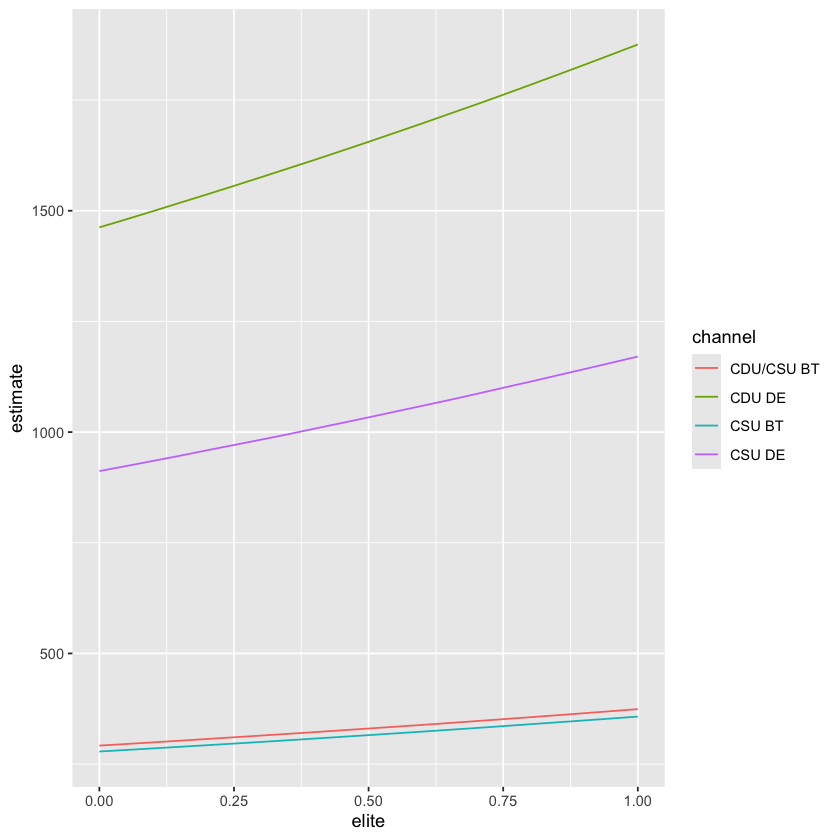

In [27]:
predictions |>
    ggplot(aes(x = elite, y = estimate, color = channel)) +
    geom_line()
